##### **Import / ladda data:**

In [181]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

test_df = pd.read_csv("../../data/testing_sample.csv")
train_df = pd.read_csv("../../data/training_sample.csv")


##### **Förstå datan:**

In [158]:
train_df.head()

,UserID,basket_icon_click,basket_add_list,basket_add_detail,sort_by,image_picker,account_page_click,promo_banner_click,detail_wishlist_add,list_size_dropdown,...,saw_sizecharts,saw_delivery,saw_account_upgrade,saw_homepage,device_mobile,device_computer,device_tablet,returning_user,loc_uk,ordered
0,a720-6b732349-a720-4862-bd21-644732,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,a0c0-6b73247c-a0c0-4bd9-8baa-797356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,86a8-6b735c67-86a8-407b-ba24-333055,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,6a3d-6b736346-6a3d-4085-934b-396834,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,b74a-6b737717-b74a-45c3-8c6a-421140,0,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,1


In [159]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 455401 entries, 0 to 455400
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   UserID                   455401 non-null  str  
 1   basket_icon_click        455401 non-null  int64
 2   basket_add_list          455401 non-null  int64
 3   basket_add_detail        455401 non-null  int64
 4   sort_by                  455401 non-null  int64
 5   image_picker             455401 non-null  int64
 6   account_page_click       455401 non-null  int64
 7   promo_banner_click       455401 non-null  int64
 8   detail_wishlist_add      455401 non-null  int64
 9   list_size_dropdown       455401 non-null  int64
 10  closed_minibasket_click  455401 non-null  int64
 11  checked_delivery_detail  455401 non-null  int64
 12  checked_returns_detail   455401 non-null  int64
 13  sign_in                  455401 non-null  int64
 14  saw_checkout             455401 non-null  int64

In [160]:
train_df.describe()

,basket_icon_click,basket_add_list,basket_add_detail,sort_by,image_picker,account_page_click,promo_banner_click,detail_wishlist_add,list_size_dropdown,closed_minibasket_click,...,saw_sizecharts,saw_delivery,saw_account_upgrade,saw_homepage,device_mobile,device_computer,device_tablet,returning_user,loc_uk,ordered
count,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,...,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000
mean,0.099150,0.074521,0.112916,0.036849,0.026735,0.003570,0.016208,0.003511,0.230362,0.017277,...,0.000389,0.005542,0.001096,0.290024,0.680706,0.194220,0.128364,0.534915,0.933224,0.041926
std,0.298864,0.262617,0.316490,0.188391,0.161307,0.059647,0.126274,0.059151,0.421065,0.130302,...,0.019711,0.074241,0.033084,0.453773,0.466204,0.395599,0.334495,0.498780,0.249634,0.200420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [161]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (455401, 25)
Testing shape: (151655, 25)


---
**EDA analys:**

In [162]:
train_df['ordered'].value_counts()

ordered
0    436308
1     19093
Name: count, dtype: int64

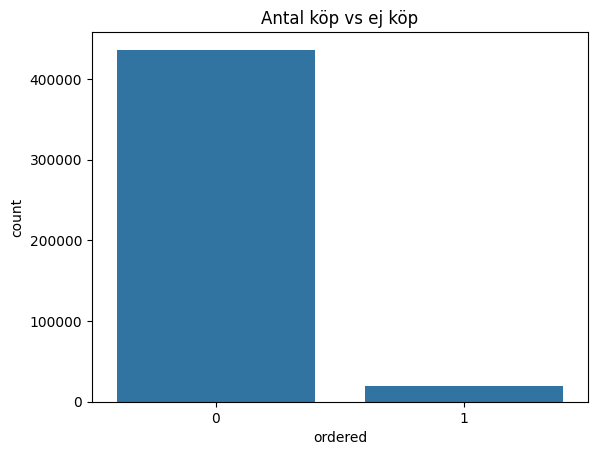

In [163]:
sns.countplot(x='ordered', data=train_df)
plt.title('Antal köp vs ej köp')
plt.show()

---
##### **Relation:**
- basket_add_detail vs ordered

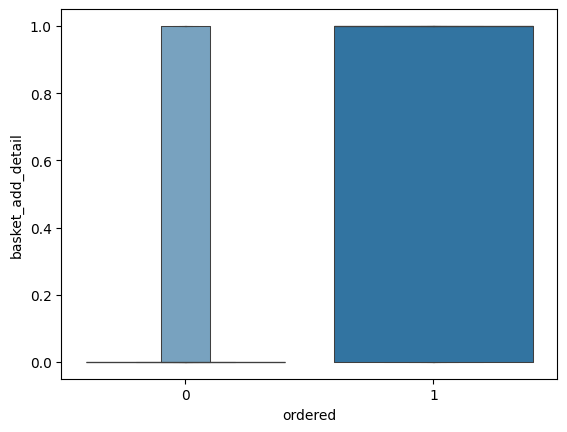

In [164]:
sns.boxenplot(x='ordered', y='basket_add_detail', data=train_df)
plt.show()

**Boxplot tolkning:**
- Nästan alla värden är 0
- Några få är 1

**Det betyder:**
- Variabeln är binär (0/1)
- Boxplot blir då ganska meningslös (för lite variation)

---
##### **EDA - jämför medelvärde per grupp**
Tolkning:
- Hur ofta klickar folk på “add detail” om de köper vs inte?

In [165]:
train_df.groupby('ordered')['basket_add_detail'].mean()

ordered
0    0.085479
1    0.739905
Name: basket_add_detail, dtype: float64

##### **EDA - jämför flera features:**

In [166]:
features = [
    'basket_add_list',
    'basket_add_detail',
    'detail_wishlist_add',
    'promo_banner_click',
    'returning_user'
]

for col in features:
    print(col)
    print(train_df.groupby('ordered')[col].mean())
    print('------')

basket_add_list
ordered
0    0.058718
1    0.435657
Name: basket_add_list, dtype: float64
------
basket_add_detail
ordered
0    0.085479
1    0.739905
Name: basket_add_detail, dtype: float64
------
detail_wishlist_add
ordered
0    0.003220
1    0.010161
Name: detail_wishlist_add, dtype: float64
------
promo_banner_click
ordered
0    0.014714
1    0.050333
Name: promo_banner_click, dtype: float64
------
returning_user
ordered
0    0.528624
1    0.678678
Name: returning_user, dtype: float64
------


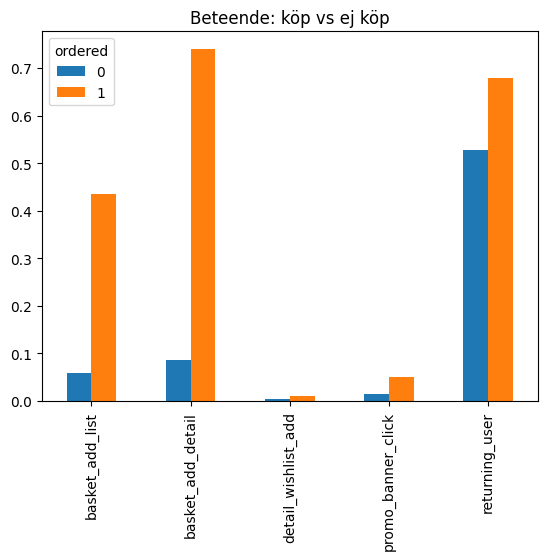

In [167]:
train_df.groupby('ordered')[features].mean().T.plot(kind='bar')
plt.title('Beteende: köp vs ej köp')
plt.show()

##### **Tolkning:**  

**Starka signaler**
- basket_add_detail	0.08 → 0.74	EXTREMT stark
- basket_add_list	0.05 → 0.43	Mycket stark  
-> “Personen är redan på väg att köpa”

**Svaga signaler**
- wishlist
- promo_banner  
-> Nästan irrelevant jämfört med andra

Handlingar nära köp (lägga i varukorg) är mycket starkare än demografiska faktorer (returning_user).

---
##### **Förbereder för modell:**

In [168]:
features = [
    'basket_add_detail',
    'basket_add_list',
    'returning_user',
    'promo_banner_click'
]

X = train_df[features]
y = train_df['ordered']

##### **Train/ Test split:**  
(stratify=y är superviktigt här pga obalanserad data)

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [170]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
ordered
0    0.958075
1    0.041925
Name: proportion, dtype: float64

Test:
ordered
0    0.95807
1    0.04193
Name: proportion, dtype: float64


---
##### **Logistic Regression:**

In [171]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

##### **Första utvärderingen:**

In [172]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9575652441233627


##### **Tolkning:**  
Eftersom datan är obalanserad får modellen ~95% accuracy bara genom att gissa “0” hela tiden.

##### **Classification Report:**

In [173]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     87262
           1       0.37      0.02      0.03      3819

    accuracy                           0.96     91081
   macro avg       0.66      0.51      0.50     91081
weighted avg       0.93      0.96      0.94     91081



##### **Problem:**
Recall = 0.02  
→ modellen hittar bara 2% av alla köp

= 98% av köpen missas.

Tolkning:  
Modellen är bra på att identifiera icke-köp, men misslyckas nästan helt med att identifiera faktiska köp.

##### **Varför det händer:**
Modellen optimerar:
- “Minimera fel totalt”

Och då väljer den:
- “Ignorera minoritetsklassen (köp)”

---
##### **Förbättra modellen:**  
Använder class_weight

In [174]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

##### **Ny utvärdering:**

In [175]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.88      0.94     87262
           1       0.25      0.89      0.39      3819

    accuracy                           0.88     91081
   macro avg       0.62      0.89      0.66     91081
weighted avg       0.96      0.88      0.91     91081



##### **Tolkning:**
Recall (1): 0.89
Precision (1): 0.25

Fångar nu:  
89% av alla köp.  
Vilket är extremt mycket bättre.

Observation:  
Precision = 0.25  
Av alla vi tror kommer köpa = bara 25% gör det.

##### **Utvärdering:**
Genom att hantera obalanserad data med class_weight förbättrades modellens förmåga att identifiera köp avsevärt (recall från 2% till 89%), men på bekostnad av precision.

##### **Viktig reflektion**

Frågan vi behöver ställa oss:

Vad är viktigast i verkligheten?

**Scenario 1:**  
Vi vill inte missa köp  
-> nuvarande modell är bra  
**Scenario 2:**  
Vi vill bara kontakta “säkra köpare”  
-> precision är för låg  

---
##### **KNN**  
Testar för jämförelse

In [176]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     87262
           1       0.00      0.00      0.00      3819

    accuracy                           0.96     91081
   macro avg       0.48      0.50      0.49     91081
weighted avg       0.92      0.96      0.94     91081



c:\Users\emmyk\dev\tdm\Shopping-online-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\emmyk\dev\tdm\Shopping-online-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\emmyk\dev\tdm\Shopping-online-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

##### **Vad som händer:**
Recall (1): 0.00  
Precision (1): 0.00  
-> Modellen hittar inte ett enda köp  
-> Den gissar bara 0 (ingen köp)

**Varför KNN misslyckas här:**

KNN tänker så här:  
-> “Jag kollar mina närmaste grannar”

Men:  
96% av alla datapunkter = 0  
Närmaste grannar = nästan alltid 0

Så modellen säger:  
-> “Det här är också 0”

**Viktig insikt:**  
KNN presterade dåligt på grund av obalanserad data, där majoritetsklassen dominerar närhetsbaserade beslut.

**Slutsats:**
Modeller som Logistic Regression kan hantera obalanser bättre med rätt inställningar, medan KNN misslyckas eftersom den baseras på närhet och påverkas starkt av majoritetsklassen.

---
##### **Rädda KNN**
Testar att förbättra KNN genom att hantera obalansen

In [177]:
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     87262
           1       0.00      0.00      0.00      3819

    accuracy                           0.96     91081
   macro avg       0.48      0.50      0.49     91081
weighted avg       0.92      0.96      0.94     91081



c:\Users\emmyk\dev\tdm\Shopping-online-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\emmyk\dev\tdm\Shopping-online-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\emmyk\dev\tdm\Shopping-online-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

---
##### **Förbättra Logistic Regression:**
**Problemet:**  
Vid obalanserad data är 0.5 ofta för högt

**Lösning:**
- Ta ut sannolikheter istället
- Sätt egen threshold
- Utvärdera igen

In [178]:
y_proba = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.99      0.88      0.94     87262
           1       0.25      0.89      0.39      3819

    accuracy                           0.88     91081
   macro avg       0.62      0.89      0.66     91081
weighted avg       0.96      0.88      0.91     91081



In [180]:
for t in [0.7, 0.5, 0.1]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     87262
           1       0.26      0.84      0.40      3819

    accuracy                           0.89     91081
   macro avg       0.63      0.87      0.67     91081
weighted avg       0.96      0.89      0.92     91081


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.99      0.88      0.94     87262
           1       0.25      0.89      0.39      3819

    accuracy                           0.88     91081
   macro avg       0.62      0.89      0.66     91081
weighted avg       0.96      0.88      0.91     91081


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      0.43      0.60     87262
           1       0.07      1.00      0.13      3819

    accuracy                           0.45     91081
   macro avg       0.54      0.71      0.37     91081
weighted avg       0.96   

**Vad vi gör här:**

Vi säger:  
“Fånga hellre fler köp, även om det ger fler falska positiva”

**Tolkning**  
Threshold 0.3 och 0.5 gav nästan samma resultat.

Det betyder:  
Modellen är ganska “säker” i sina predictioner.  
Den är inte superkänslig för små förändringar.  

---
##### **PCA - med rätt förväntningar:**

1. Skala datan
2. PCA
3. Förklara varians
4. Visualisera  
-> Detta visar hur mycket information vi behåller

In [184]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.352834   0.24644682]


##### **PCA-projection - dimensionalitetsreduktion:**

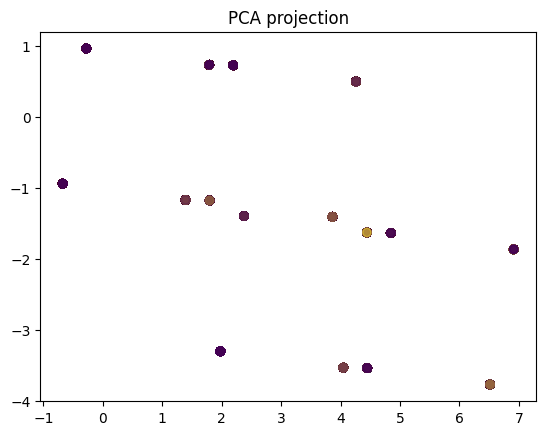

In [185]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.3)
plt.title("PCA projection")
plt.show()

##### **Tolkning:**
PCA visade att datan inte är linjärt separerbar i två dimensioner, vilket indikerar att dimensionalitetsreduktion inte förbättrar modellens prestanda i detta fall.

##### **Kör modell på PCA-data:**

In [186]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

model_pca = LogisticRegression(class_weight="balanced")
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)

print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       0.99      0.87      0.93     87262
           1       0.24      0.89      0.37      3819

    accuracy                           0.87     91081
   macro avg       0.62      0.88      0.65     91081
weighted avg       0.96      0.87      0.91     91081



##### **Viktig insikt**
När threshold sänks:
- Recall ↑ (fångar fler köp)
- Precision ↓ (fler fel)

-> Att justera threshold gav begränsad förbättring eftersom modellen redan prioriterade recall genom class balancing.

---
##### **Kolla feature importance (för Logistic)**  
Vilka variabler driver köp enligt modellen?

In [187]:
importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

importance.sort_values(by="coefficient", ascending=False)

,feature,coefficient
0,basket_add_detail,3.646883
1,basket_add_list,2.758631
2,returning_user,0.907612
3,promo_banner_click,-0.030009


---
##### **Slutinsikt**
Beteendedata nära köp (som att lägga produkter i varukorg) är de starkaste prediktorerna, medan dimensionalitetsreduktion och närhetsbaserade modeller inte förbättrar resultatet i detta fall.